In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
heart = pd.read_csv('heart_disease_uci.csv')

In [3]:
heart.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [4]:
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [6]:
heart.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [7]:
heart.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [8]:
heart.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [9]:
heart[heart['trestbps'].isnull()]

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
393,394,48,Female,Hungary,atypical angina,NaN,308.0,False,st-t abnormality,NaN,NaN,2.0,upsloping,NaN,NaN,0
599,600,35,Male,Switzerland,asymptomatic,NaN,0.0,NaN,normal,130.0,True,NaN,NaN,NaN,reversable defect,3
714,715,69,Male,Switzerland,asymptomatic,NaN,0.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,reversable defect,3
733,734,63,Male,VA Long Beach,non-anginal,NaN,0.0,False,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,1
743,744,74,Male,VA Long Beach,non-anginal,NaN,0.0,False,normal,NaN,NaN,NaN,NaN,NaN,NaN,0
746,747,51,Male,VA Long Beach,asymptomatic,NaN,0.0,True,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,2
749,750,55,Male,VA Long Beach,non-anginal,NaN,228.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,3
750,751,54,Male,VA Long Beach,asymptomatic,NaN,0.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,3
756,757,60,Male,VA Long Beach,asymptomatic,NaN,281.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,2
758,759,58,Male,VA Long Beach,asymptomatic,NaN,203.0,True,normal,NaN,NaN,NaN,NaN,NaN,NaN,1


In [11]:
heart[heart['chol'] == 0.0]

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
597,598,32,Male,Switzerland,typical angina,95.0,0.0,NaN,normal,127.0,False,0.7,upsloping,NaN,NaN,1
598,599,34,Male,Switzerland,asymptomatic,115.0,0.0,NaN,NaN,154.0,False,0.2,upsloping,NaN,NaN,1
599,600,35,Male,Switzerland,asymptomatic,NaN,0.0,NaN,normal,130.0,True,NaN,NaN,NaN,reversable defect,3
600,601,36,Male,Switzerland,asymptomatic,110.0,0.0,NaN,normal,125.0,True,1.0,flat,NaN,fixed defect,1
601,602,38,Female,Switzerland,asymptomatic,105.0,0.0,NaN,normal,166.0,False,2.8,upsloping,NaN,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
818,819,43,Male,VA Long Beach,asymptomatic,122.0,0.0,False,normal,120.0,False,0.5,upsloping,NaN,NaN,1
819,820,63,Male,VA Long Beach,non-anginal,130.0,0.0,True,st-t abnormality,160.0,False,3.0,flat,NaN,NaN,0
822,823,48,Male,VA Long Beach,non-anginal,102.0,0.0,NaN,st-t abnormality,110.0,True,1.0,downsloping,NaN,NaN,1
839,840,56,Male,VA Long Beach,asymptomatic,NaN,0.0,False,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,1


In [12]:
age_cp = heart.groupby(['age','cp']).size().unstack()
age_cp

cp,asymptomatic,atypical angina,non-anginal,typical angina
age,,,,
28,NaN,1.0,NaN,NaN
29,NaN,3.0,NaN,NaN
30,NaN,NaN,NaN,1.0
31,1.0,1.0,NaN,NaN
32,1.0,3.0,NaN,1.0
33,1.0,NaN,1.0,NaN
34,1.0,4.0,NaN,2.0
35,5.0,4.0,1.0,1.0
36,1.0,2.0,3.0,NaN


In [13]:
heart.duplicated().sum()

np.int64(0)

In [16]:
heart[['age','thalch','chol','trestbps','oldpeak']].describe()

,age,thalch,chol,trestbps,oldpeak
count,920.000000,865.000000,890.000000,861.000000,858.000000
mean,53.510870,137.545665,199.130337,132.132404,0.878788
std,9.424685,25.926276,110.780810,19.066070,1.091226
min,28.000000,60.000000,0.000000,0.000000,-2.600000
25%,47.000000,120.000000,175.000000,120.000000,0.000000
50%,54.000000,140.000000,223.000000,130.000000,0.500000
75%,60.000000,157.000000,268.000000,140.000000,1.500000
max,77.000000,202.000000,603.000000,200.000000,6.200000


Text(0.5, 1.0, 'Age Wise Distribution of People')

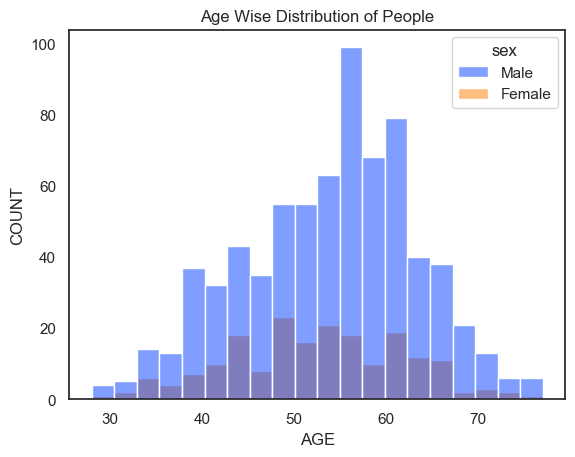

In [32]:
sns.set_theme(style="white", palette="bright")
sns.histplot(data = heart, x = 'age', bins=20, hue = 'sex')
plt.xlabel("AGE")
plt.ylabel("COUNT")
plt.title("Age Wise Distribution of People")

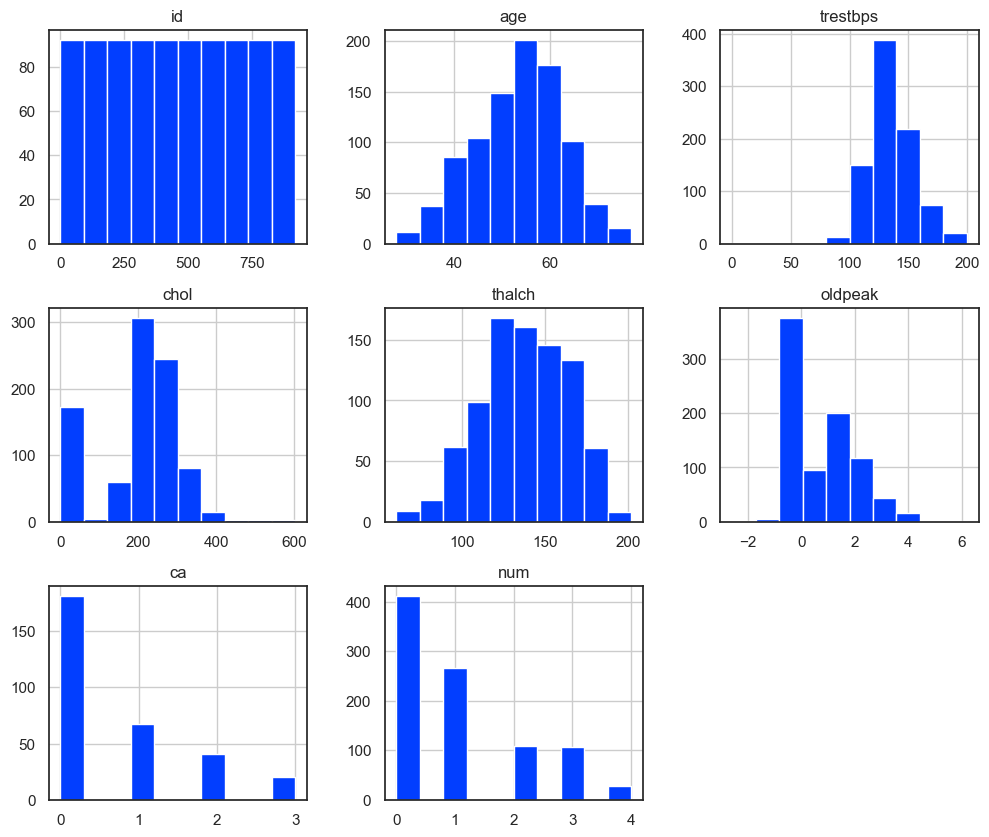

In [52]:
heart.hist(figsize=(12,10))
plt.show()

In [15]:
heart['num'].value_counts()

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

In [17]:
heart['sex'].value_counts()

sex
Male      726
Female    194
Name: count, dtype: int64

In [19]:
heart.groupby('sex')['chol'].mean()

sex
Female    241.481283
Male      187.864865
Name: chol, dtype: float64

In [20]:
pd.crosstab(heart['sex'], heart['num'])

num,0,1,2,3,4
sex,,,,,
Female,144,30,10,8,2
Male,267,235,99,99,26


In [18]:
heart['cp'].value_counts()

cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64

In [21]:
heart.sample(5)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
660,661,57,Male,Switzerland,non-anginal,105.0,0.0,NaN,normal,148.0,False,0.3,flat,NaN,NaN,1
909,910,68,Male,VA Long Beach,non-anginal,134.0,254.0,True,normal,151.0,True,0.0,NaN,NaN,normal,0
716,717,70,Male,Switzerland,asymptomatic,140.0,0.0,True,normal,157.0,True,2.0,flat,NaN,reversable defect,3
884,885,51,Male,VA Long Beach,asymptomatic,NaN,NaN,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,reversable defect,1
798,799,60,Male,VA Long Beach,asymptomatic,142.0,216.0,False,normal,110.0,True,2.5,flat,NaN,NaN,2


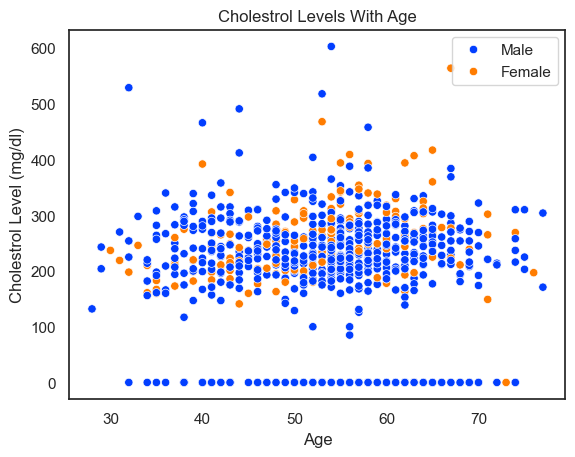

In [33]:
sns.scatterplot(data = heart ,x = 'age',y = 'chol', hue = 'sex')
plt.title('Cholestrol Levels With Age')
plt.xlabel('Age')
plt.ylabel('Cholestrol Level (mg/dl)')
plt.legend()
plt.show()

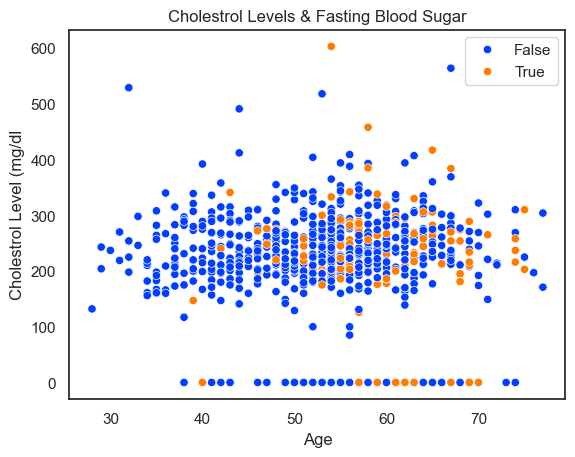

In [62]:
sns.scatterplot(x="age", y="chol", data=heart, hue = 'fbs')
plt.title('Cholestrol Levels & Fasting Blood Sugar')
plt.xlabel('Age')
plt.ylabel('Cholestrol Level (mg/dl')
plt.legend()
plt.show()

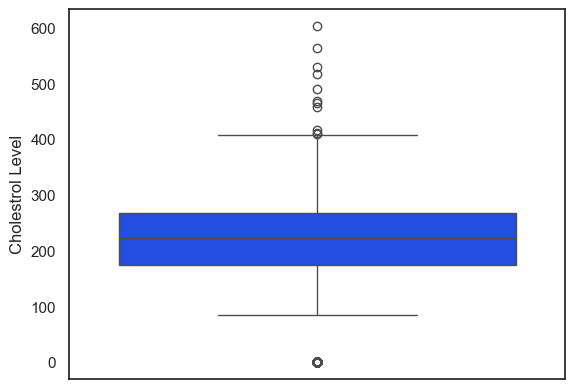

In [90]:
sns.boxplot(y=heart['chol'])
plt.ylabel('Cholestrol Level')
plt.show()


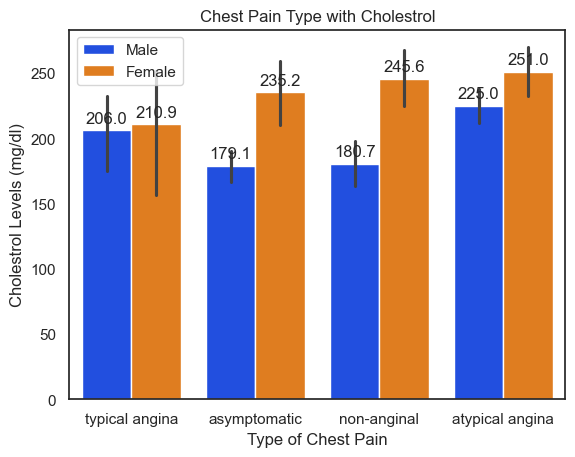

In [91]:
ax = sns.barplot(data=heart, x='cp', y='chol', hue = 'sex')
plt.title('Chest Pain Type with Cholestrol')
plt.xlabel('Type of Chest Pain')
plt.ylabel('Cholestrol Levels (mg/dl)')

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)

plt.legend()
plt.show()

In [35]:
heart.groupby('sex')['chol'].mean()

sex
Female    241.481283
Male      187.864865
Name: chol, dtype: float64

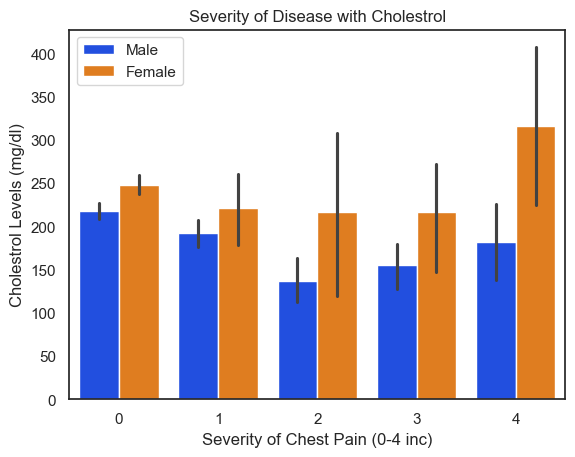

In [36]:
sns.barplot(data=heart, x='num', y='chol', hue = 'sex')
plt.title('Severity of Disease with Cholestrol')
plt.xlabel('Severity of Chest Pain (0-4 inc)')
plt.ylabel('Cholestrol Levels (mg/dl)')
plt.legend()
plt.show()

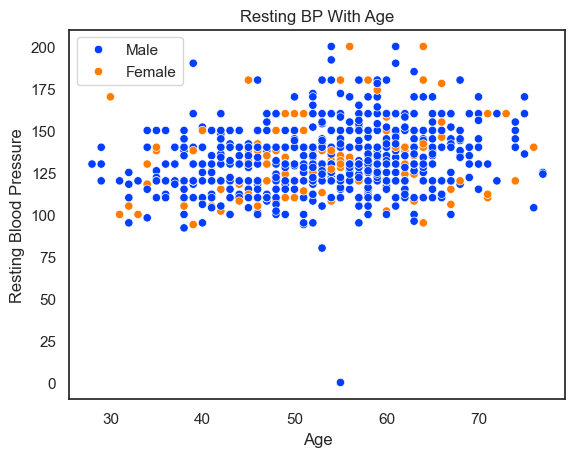

In [48]:
sns.scatterplot(data = heart ,x = 'age',y = 'trestbps', hue = 'sex')
plt.title('Resting BP With Age')
plt.xlabel('Age')
plt.ylabel('Resting Blood Pressure')
plt.legend()
plt.show()

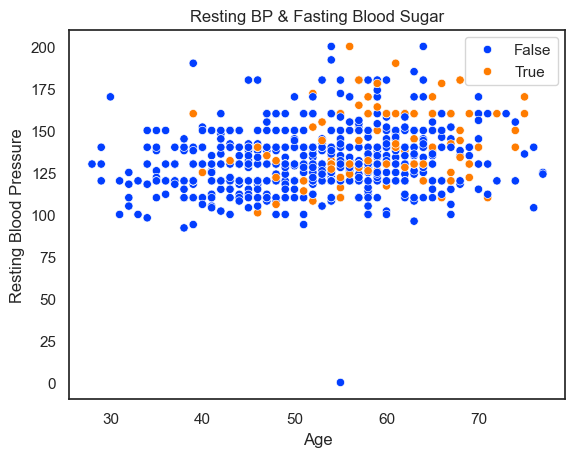

In [61]:
sns.scatterplot(x="age", y="trestbps", data=heart, hue = 'fbs')
plt.title('Resting BP & Fasting Blood Sugar')
plt.xlabel('Age')
plt.ylabel('Resting Blood Pressure')
plt.legend()
plt.show()

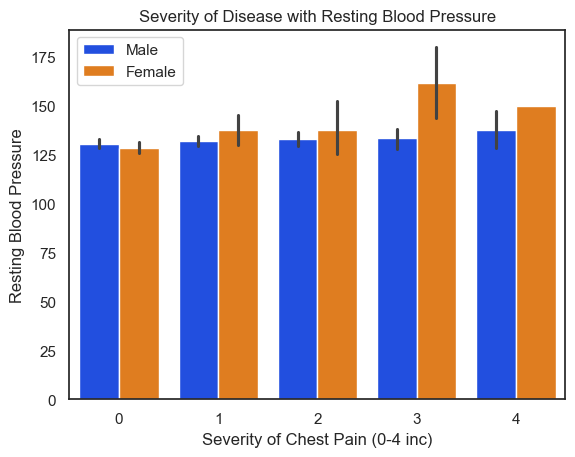

In [40]:
sns.barplot(data=heart, x='num', y='trestbps', hue = 'sex')
plt.title('Severity of Disease with Resting Blood Pressure')
plt.xlabel('Severity of Chest Pain (0-4 inc)')
plt.ylabel('Resting Blood Pressure')
plt.legend()
plt.show()

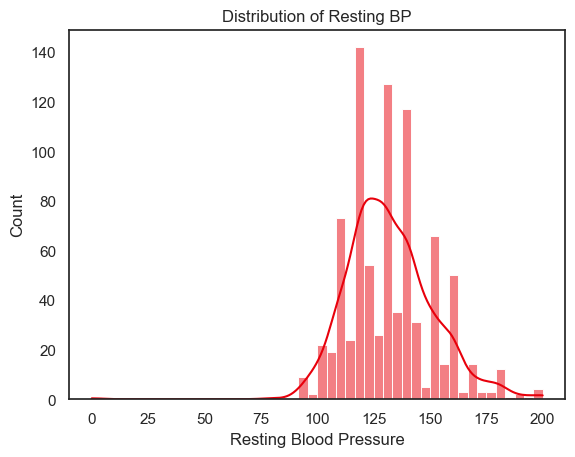

In [49]:
sns.histplot(data=heart, x='trestbps', kde=True,color = 'r')
plt.title('Distribution of Resting BP')
plt.xlabel('Resting Blood Pressure')
plt.show()

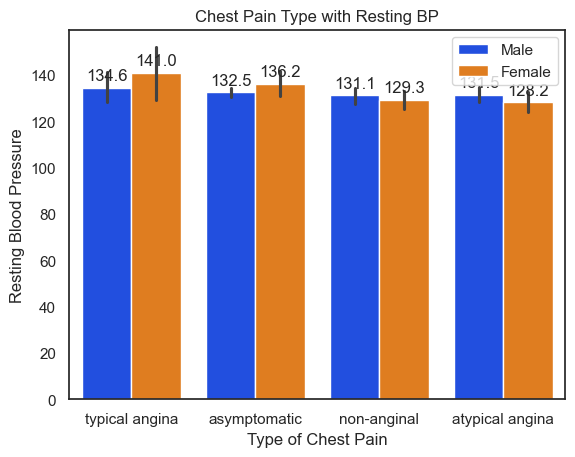

In [50]:
ax = sns.barplot(data=heart, x='cp', y='trestbps', hue = 'sex')
plt.title('Chest Pain Type with Resting BP')
plt.xlabel('Type of Chest Pain')
plt.ylabel('Resting Blood Pressure')

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)

plt.legend()
plt.show()

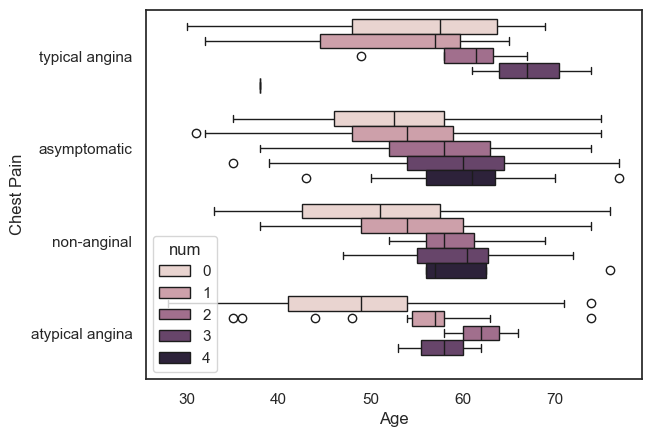

In [54]:
sns.boxplot(data = heart, x="age", y="cp", hue = 'num')
plt.xlabel('Age')
plt.ylabel('Chest Pain')
plt.show()

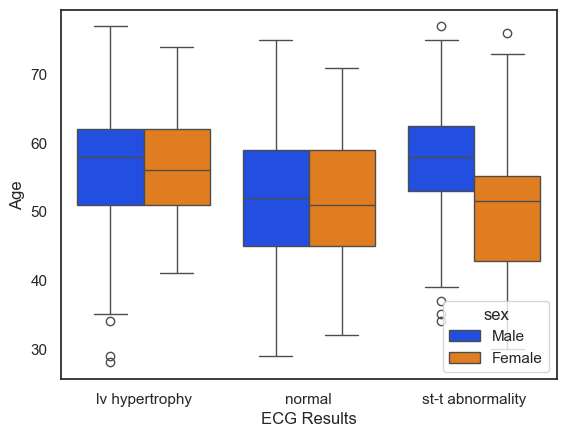

In [55]:
sns.boxplot(x="restecg", y="age", data=heart, hue = 'sex')
plt.xlabel('ECG Results')
plt.ylabel('Age')
plt.show()

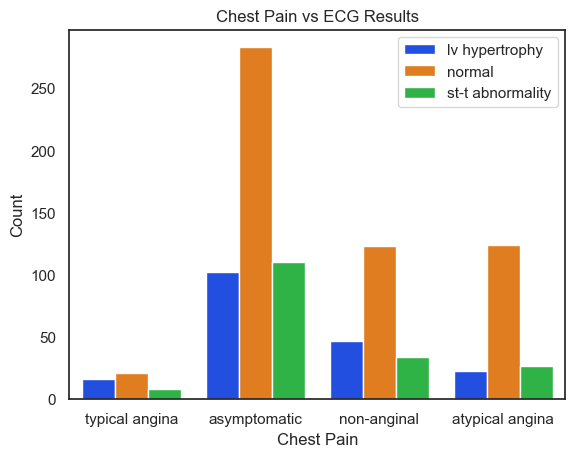

In [57]:
sns.countplot(x="cp", hue="restecg", data=heart)
plt.title('Chest Pain vs ECG Results')
plt.xlabel('Chest Pain')
plt.ylabel('Count')
plt.legend()
plt.show()

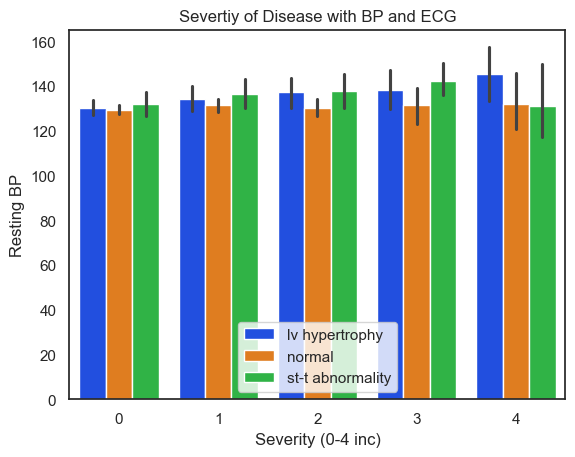

In [58]:
sns.barplot(data = heart, y = 'trestbps', x ='num', hue = 'restecg')
plt.title('Severtiy of Disease with BP and ECG')
plt.xlabel('Severity (0-4 inc)')
plt.ylabel('Resting BP')
plt.legend()
plt.show()

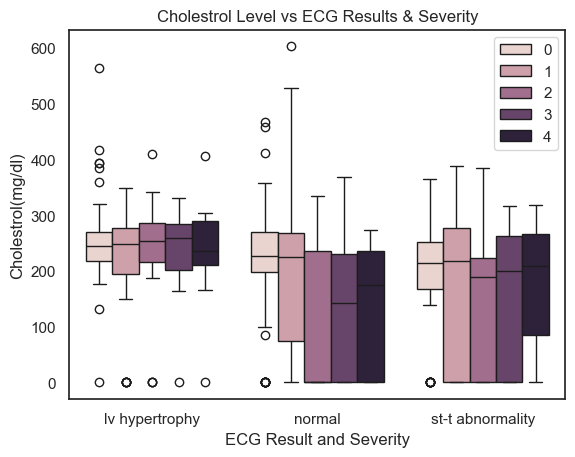

In [63]:
sns.boxplot(x="restecg", y="chol", data=heart, hue = 'num')
plt.title('Cholestrol Level vs ECG Results & Severity')
plt.xlabel('ECG Result and Severity')
plt.ylabel('Cholestrol(mg/dl)')
plt.legend()
plt.show()

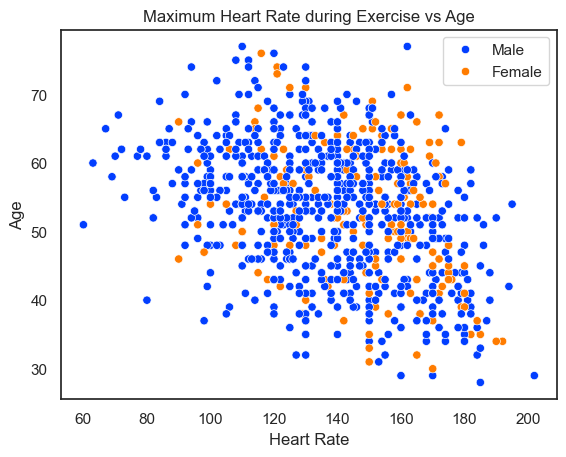

In [64]:
sns.scatterplot(x="thalch",y = 'age', data=heart, hue = 'sex')
plt.title('Maximum Heart Rate during Exercise vs Age'),
plt.xlabel('Heart Rate')
plt.ylabel('Age')
plt.legend()
plt.show()

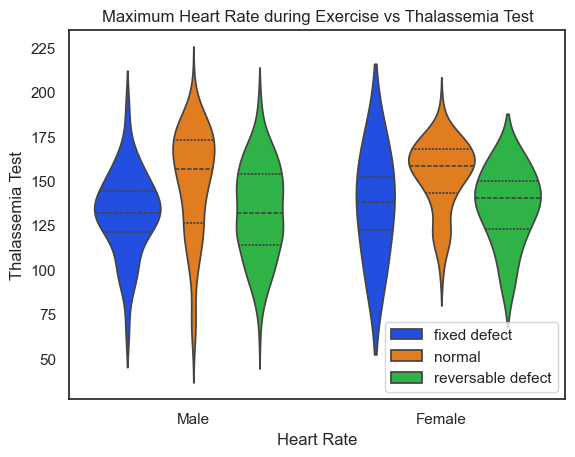

In [65]:
sns.violinplot(data = heart, x = 'sex' ,y = 'thalch' , hue = 'thal', inner = 'quart')
plt.title('Maximum Heart Rate during Exercise vs Thalassemia Test'),
plt.xlabel('Heart Rate')
plt.ylabel('Thalassemia Test')
plt.legend()
plt.show()

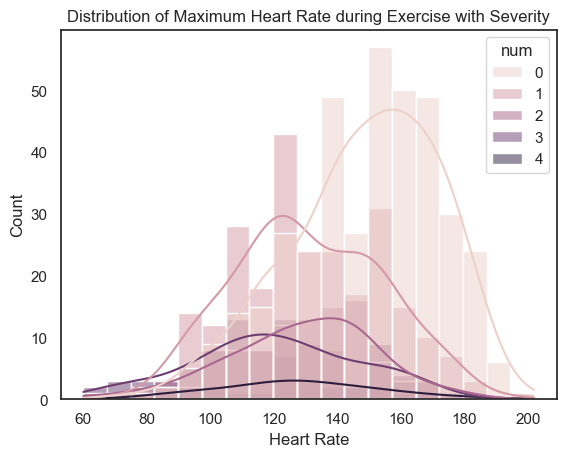

In [69]:
sns.histplot(data=heart, x='thalch', kde=True,hue = 'num')
plt.title('Distribution of Maximum Heart Rate during Exercise with Severity')
plt.xlabel('Heart Rate')
plt.show()

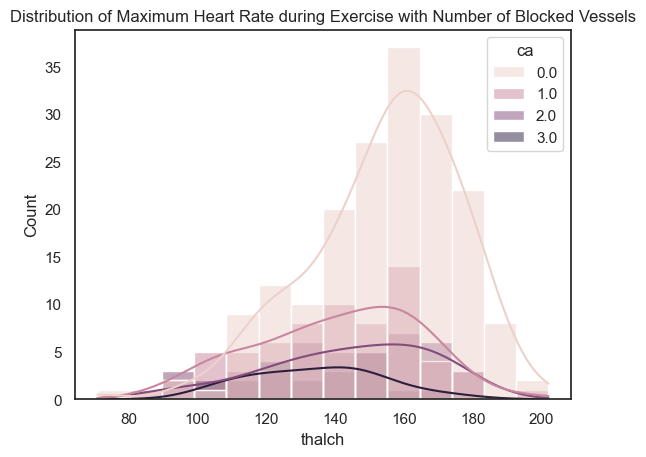

In [70]:
sns.histplot(data=heart, x='thalch', kde=True,hue = 'ca')
plt.title('Distribution of Maximum Heart Rate during Exercise with Number of Blocked Vessels')
plt.show()

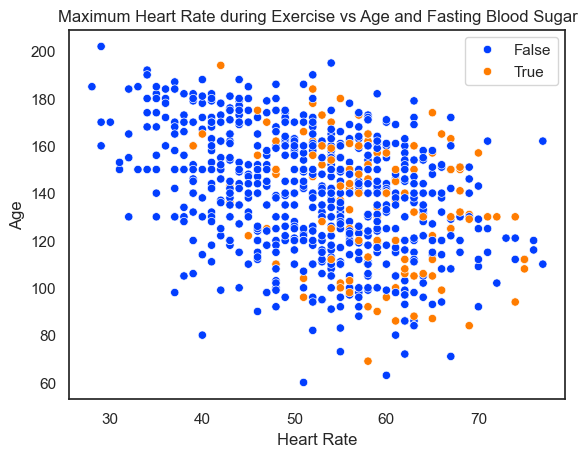

In [72]:
sns.scatterplot(x="age", y="thalch", data=heart, hue = 'fbs')
plt.title('Maximum Heart Rate during Exercise vs Age and Fasting Blood Sugar'),
plt.xlabel('Heart Rate')
plt.ylabel('Age')
plt.legend()
plt.show()

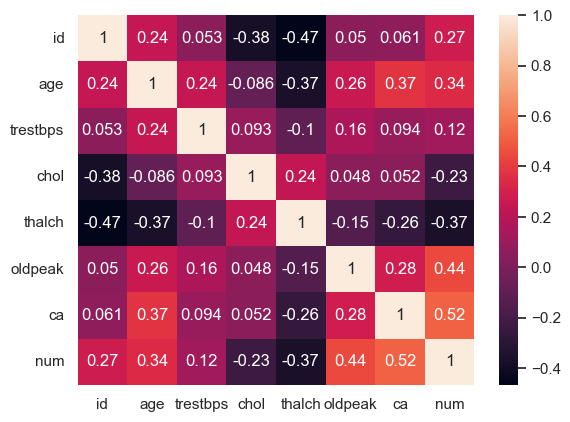

In [74]:
corr = heart.corr(numeric_only = True)
sns.heatmap(corr, annot=True)
plt.show()

In [75]:
heart['age_group'] = pd.cut(heart['age'], bins=[29,40,50,60,80], labels=['Young','Middle','Senior','Elder'])

In [76]:
heart['age_group'].value_counts()

age_group
Senior    382
Middle    224
Elder     221
Young      89
Name: count, dtype: int64

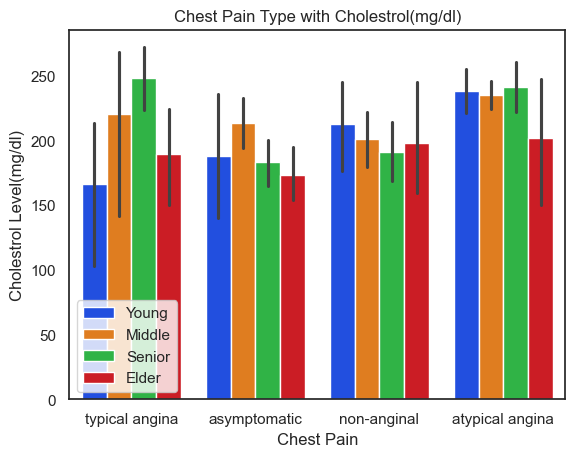

In [78]:
sns.barplot(data=heart, x='cp', y='chol',hue = 'age_group')
plt.title('Chest Pain Type with Cholestrol(mg/dl)')
plt.ylabel('Cholestrol Level(mg/dl)')
plt.xlabel('Chest Pain')
plt.legend()
plt.show()

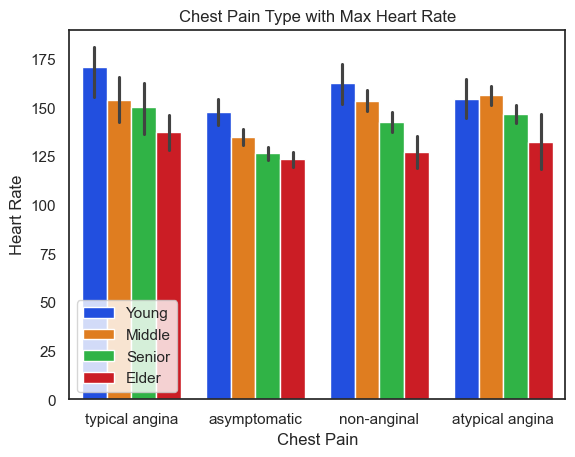

In [79]:
sns.barplot(data=heart, x='cp', y='thalch',hue = 'age_group')
plt.title('Chest Pain Type with Max Heart Rate')
plt.ylabel('Heart Rate')
plt.xlabel('Chest Pain')
plt.legend()
plt.show()

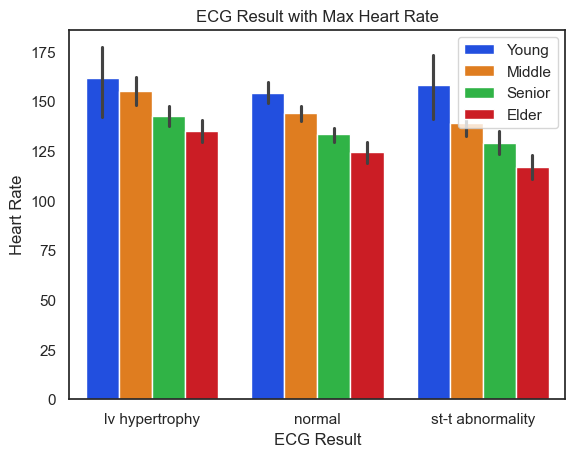

In [80]:
sns.barplot(data=heart, x='restecg', y='thalch',hue = 'age_group')
plt.title('ECG Result with Max Heart Rate')
plt.ylabel('Heart Rate')
plt.xlabel('ECG Result')
plt.legend()
plt.show()

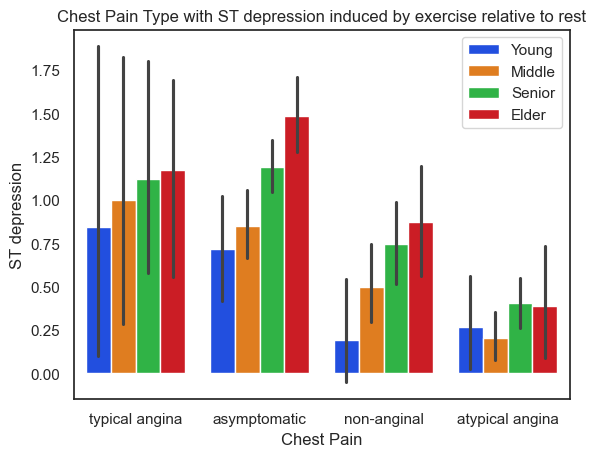

In [86]:
sns.barplot(data=heart, x='cp', y='oldpeak',hue = 'age_group')
plt.title('Chest Pain Type with ST depression induced by exercise relative to rest')
plt.ylabel('ST depression')
plt.xlabel('Chest Pain')
plt.legend()
plt.show()

In [96]:
heart['riskscore'] = heart[['ca', 'num','oldpeak']].sum(axis=1)

In [97]:
heart['riskscore']

0      2.3
1      6.5
2      5.6
3      3.5
4      1.4
      ... 
915    1.0
916    0.0
917    2.0
918    0.0
919    1.0
Name: riskscore, Length: 920, dtype: float64